In [1]:
# ============================================
# Standard library imports
# ============================================
import re
import sys
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
import itertools
from pathlib import Path

from IPython.display import display

warnings.filterwarnings("ignore")


# ============================================
# Numeric / statistics
# ============================================
import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import rankdata


# ============================================
# Plotting / visualization
# ============================================
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

import seaborn as sns

from upsetplot import UpSet, from_memberships


# ============================================
# scikit-learn
# ============================================
from sklearn import model_selection, metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn import __version__ as sklearn_version


# ============================================
# Optimization
# ============================================
import optuna


# ============================================
# RNA structure
# Later this can be removed if all structure features are precomputed by script.
# ============================================
import RNA


# ============================================
# Model explanation
# ============================================
import shap


# ============================================
# User utilities
# ============================================
import sylib


# ============================================
# Version info
# ============================================
print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"optuna    = {optuna.__version__}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"sylib     = {sylib.__version__}")


# ============================================
# Logging
# ============================================
logging.root.handlers = []

stream_handler = logging.StreamHandler(sys.stderr)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)

logger = logging.getLogger(__name__)

logging.getLogger("matplotlib").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
sklearn   = 1.9.0
optuna    = 4.9.0
ViennaRNA = 2.7.2
sylib     = 0.3.0.dev0+ae18bb2


In [2]:
# ============================================
# Plotting configuration & helpers
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}

def set_plot_style(
    *,
    font_size=14,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    tight_layout=True,
    fig_w=6.0,
    fig_h=6.0,
):
    """
    Neutral, publication-ready plotting style.
    (based on your original config)
    """
    sns.set_style("ticks")
    mpl.rcParams.update({
        "font.size": font_size,
        "figure.dpi": dpi,
        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,
        "axes.grid": grid,
    })
    _PLOT_CFG.update({"fig_w": fig_w, "fig_h": fig_h, "dpi": dpi})
    if tight_layout:
        plt.rcParams["figure.autolayout"] = False


def make_fig(w=None, h=None, dpi=None):
    """
    Convenience helper using global defaults unless overridden.
    """
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]
    fig, ax = plt.subplots(figsize=(W, H), dpi=D)
    return fig, ax


def _compact_formatter():
    """
    Tick formatter for compact notation (k, M, B).
    """
    def _fmt(x, _pos=None):
        axx = abs(x)
        if axx >= 1e9:
            s = f"{x/1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x/1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x/1e3:.1f}k"
        else:
            s = f"{int(x):d}"
        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )
    return FuncFormatter(_fmt)


def format_axis(ax, *, xlabel=None, ylabel=None, compact_ticks=("x", "y")):
    """
    Apply axis labels and optional compact tick formatting.
    """
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()
    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)
    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)
    return ax


# ============================================
# Joint scatter with KDE marginals
# (your original joint_scatter, generalized)
# ============================================

from matplotlib.gridspec import GridSpec

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    grid = np.linspace(lo, hi, num)
    if len(values) < 2:
        return grid, np.zeros_like(grid)
    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens
    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    """
    Generic joint scatter with top/right KDE marginals.
    Re-usable for any variables (true vs predicted, etc.).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = len(x)

    # figure size resolution
    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(figsize=(FW, FH), dpi=(dpi or _PLOT_CFG["dpi"]))

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )
    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    # main scatter
    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    lo -= pad
    hi += pad
    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    # y = x identity line
    if show_identity:
        ax_joint.plot([lo, hi], [lo, hi], ls="--", lw=1.2, color="0.65", zorder=1)

    # regression line
    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(ax_joint, xlabel=xlabel, ylabel=ylabel, compact_ticks=(),)
    if title:
        ax_joint.set_title(title)

    # annotation: Pearson r, n
    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp = np.corrcoef(x, y)[0, 1]
        ax_joint.text(
            0.04,
            0.96,
            rf"$r_p = {rp:.2f}$" + f"\n$n = {n}$",
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    # marginals (KDE normalized)
    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)
    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")
    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()
    return fig, (ax_joint, ax_top, ax_right)

set_plot_style()


In [3]:
# ============================================
# Inspect available raw input files
# ============================================

RAW = Path("../data/raw")

files = sorted(RAW.glob("*.tsv.gz"))

for f in files:
    print(f.name)

AT21.PR_var.N50-TSL0-ARL0.RNA.seq_data.tsv.gz
AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
NB21.PR_var.N50-TSL0-ARL0.RNA.seq_data.tsv.gz
NB21.PR_var.dev_data.RNA.seq_data.tsv.gz
OS21.PR_var.N50-TSL0-ARL0.RNA.seq_data.tsv.gz
OS21.PR_var.dev_data.RNA.seq_data.tsv.gz


In [4]:
# ============================================
# Load sequence data
# ============================================

DATA_DIR = Path("../data/raw")

score_col_name = "PR_var"
group_col_name = None

rna_temp = 25

seq_file = DATA_DIR / "AT21.PR_var.dev_data.RNA.seq_data.tsv.gz"

seq_df, metadata = sylib.fileio.load_df(
    str(seq_file)
)

metadata.print_minimum_data(
    label="Sequence data",
    logger=logger,
    logging_level="info",
)

print(f"Input file : {seq_file.name}")
print(f"Shape      : {seq_df.shape}")

display(seq_df.head())

2026-06-19 21:26:49,239     INFO: Sequence data |   name = AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
2026-06-19 21:26:49,240     INFO: Sequence data |    md5 = 463f63c03bb16bfb05e1f6ea025947b8
2026-06-19 21:26:49,240     INFO: Sequence data | md5_gz = 7940f4f1aa886ba02c249422c074027e


Input file : AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
Shape      : (65, 11)


,var_id,trans_id,gene_id,usage,PR_var,5'UTR,CDS,3'UTR,n_5'UTR_introns,n_CDS_introns,n_3'UTR_introns
0,AT1G07770.2.2409543.2408264,AT1G07770.2,AT1G07770,0.043245,0.408580,CUCUUCUUCCUCUAAUUGCUUUUCUCCGUCACUGAGUACCUUGCCU...,AUGGUAAGAAUCAGUGUUCUUAACGAUGCUCUCAAGAGCAUGUACA...,AGUUUUAUUUUAUGGGGAAACAGAUUUUCAUUGAGUUAUUUUUAAC...,1,2,0
1,AT1G07770.2.2409543.2408265,AT1G07770.2,AT1G07770,0.035668,0.447437,CUCUUCUUCCUCUAAUUGCUUUUCUCCGUCACUGAGUACCUUGCCU...,AUGGUAAGAAUCAGUGUUCUUAACGAUGCUCUCAAGAGCAUGUACA...,AGUUUUAUUUUAUGGGGAAACAGAUUUUCAUUGAGUUAUUUUUAAC...,1,2,0
2,AT1G07770.3.2409543.2408265,AT1G07770.3,AT1G07770,0.037044,0.626719,CUCUUCUUCCUCUAAUUGCUUUUCUCCGUCACUGAGUACCUUGCCU...,AUGGUAAGAAUCAGUGUUCUUAACGAUGCUCUCAAGAGCAUGUACA...,AGUUUUAUUUUAUGGGGAAACAGAUUUUCAUUGAGUUAUUUUUAAC...,1,2,0
3,AT1G07820.1.2421940.2421219,AT1G07820.1,AT1G07820,0.111209,0.522178,GUCAAAUUCAAUUGAUCCUCUCUCCAAAUCAUCUUAAAAGUAUCUU...,AUGUCGGGAAGAGGAAAGGGAGGAAAAGGAUUGGGAAAGGGAGGAG...,UCCGAUUUGGGGGAUUAGGGUUUAUGCAAGUUUGGGGAUUUCUUCU...,0,0,0
4,AT1G07820.2.2421937.2421219,AT1G07820.2,AT1G07820,0.079275,0.490502,AAAUUCAAUUGAUCCUCUCUCCAAAUCAUCUUAAAAUCACAGAUCU...,AUGUCGGGAAGAGGAAAGGGAGGAAAAGGAUUGGGAAAGGGAGGAG...,UCCGAUUUGGGGGAUUAGGGUUUAUGCAAGUUUGGGGAUUUCUUCU...,1,0,0


In [5]:
# ============================================
# Feature Evaluation: Definition of Features
# ============================================

def normalize_rna(seq):
    if pd.isna(seq):
        return ""
    return str(seq).upper().replace("T", "U")


def cat_full_rna(utr5_list, cds_list, utr3_list):
    return [
        normalize_rna(u5) + normalize_rna(cds) + normalize_rna(u3)
        for u5, cds, u3 in zip(utr5_list, cds_list, utr3_list)
    ]


def _all_kmers(k, is_rna=True):
    alphabet = ["A", "U", "G", "C"] if is_rna else ["A", "T", "G", "C"]
    out = []

    def rec(prefix, d):
        if d == 0:
            out.append(prefix)
            return
        for ch in alphabet:
            rec(prefix + ch, d - 1)

    rec("", k)
    return out


def _windows_for_seq(s, win, step):
    s = normalize_rna(s)
    L = len(s)

    if L == 0 or win <= 0:
        return [], []

    starts = list(range(0, max(L - win + 1, 0) + 1, step))
    return [s[i:i + win] for i in starts], starts


def eval_length(seq_list, region_name, logger=logger):
    return pd.DataFrame({
        f"{region_name}.Length": [
            len(normalize_rna(seq))
            for seq in seq_list
        ]
    })


def eval_kmer_freq(seq_list, region_name, is_rna_seq=True, k=1, logger=logger):
    seq_list = [
        normalize_rna(seq)
        for seq in seq_list
    ]

    count_dict = sylib.sequtils.count_nuc_k_mer_of_seq_list(
        seq_list,
        is_rna_seq=is_rna_seq,
        k=k,
    )

    feat_df = pd.DataFrame({
        f"{region_name}.{key}-freq": count_dict[key]
        for key in count_dict
    })

    seq_len_sr = pd.Series([
        len(seq)
        for seq in seq_list
    ])

    seq_len_sr[seq_len_sr == 0] = 1

    for col_name in feat_df.columns:
        feat_df[col_name] /= seq_len_sr
        feat_df[col_name] *= 1000

    return feat_df


def eval_s_freq(seq_list, region_name, logger=logger):
    v = []

    for seq in seq_list:
        seq = normalize_rna(seq)
        value = (seq.count("G") + seq.count("C")) / len(seq) * 1000 if len(seq) > 0 else 0.0
        v.append(value)

    return pd.DataFrame({
        f"{region_name}.S-freq": v
    })


def eval_y_freq(seq_list, region_name, logger=logger):
    v = []

    for seq in seq_list:
        seq = normalize_rna(seq)
        value = (seq.count("U") + seq.count("C")) / len(seq) * 1000 if len(seq) > 0 else 0.0
        v.append(value)

    return pd.DataFrame({
        f"{region_name}.Y-freq": v
    })


def eval_k_freq(seq_list, region_name, logger=logger):
    v = []

    for seq in seq_list:
        seq = normalize_rna(seq)
        value = (seq.count("G") + seq.count("U")) / len(seq) * 1000 if len(seq) > 0 else 0.0
        v.append(value)

    return pd.DataFrame({
        f"{region_name}.K-freq": v
    })


def eval_n_uaug(utr5_seq_list, region_name, is_rna_seq=True, logger=logger):
    seq_list = [
        normalize_rna(seq)
        for seq in utr5_seq_list
    ]

    if is_rna_seq:
        return pd.DataFrame({
            f"{region_name}.uAUG": [
                seq.count("AUG")
                for seq in seq_list
            ]
        })

    return pd.DataFrame({
        f"{region_name}.uATG": [
            seq.replace("U", "T").count("ATG")
            for seq in seq_list
        ]
    })


def eval_n_uorf(utr5_seq_list, region_name, is_rna_seq=True, logger=logger):
    feat_df_dict = {
        f"{region_name}.uORF-NO": [],
        f"{region_name}.uORF-IO": [],
        f"{region_name}.uORF-OO": [],
    }

    start_codon = "AUG" if is_rna_seq else "ATG"
    stop_codons = {"UAA", "UGA", "UAG"} if is_rna_seq else {"TAA", "TGA", "TAG"}

    for seq in utr5_seq_list:
        seq = normalize_rna(seq)
        if not is_rna_seq:
            seq = seq.replace("U", "T")

        L = len(seq)
        n_no = n_io = n_oo = 0

        for i in range(L - 2):
            if seq[i:i + 3] == start_codon:
                has_stop = False

                for j in range(i + 3, L - 2, 3):
                    if seq[j:j + 3] in stop_codons:
                        has_stop = True
                        break

                if has_stop:
                    n_no += 1
                elif (L - i) % 3 == 0:
                    n_io += 1
                else:
                    n_oo += 1

        feat_df_dict[f"{region_name}.uORF-NO"].append(n_no)
        feat_df_dict[f"{region_name}.uORF-IO"].append(n_io)
        feat_df_dict[f"{region_name}.uORF-OO"].append(n_oo)

    return pd.DataFrame(feat_df_dict)


def eval_n_daug(utr3_seq_list, region_name, is_rna_seq=True, logger=logger):
    seq_list = [
        normalize_rna(seq)
        for seq in utr3_seq_list
    ]

    if is_rna_seq:
        return pd.DataFrame({
            f"{region_name}.dAUG": [
                seq.count("AUG")
                for seq in seq_list
            ]
        })

    return pd.DataFrame({
        f"{region_name}.dATG": [
            seq.replace("U", "T").count("ATG")
            for seq in seq_list
        ]
    })


def eval_n_dorf(utr3_seq_list, region_name, is_rna_seq=True, logger=logger):
    feat_df_dict = {
        f"{region_name}.dORF": [],
        f"{region_name}.dORF-NS": [],
    }

    start_codon = "AUG" if is_rna_seq else "ATG"
    stop_codons = {"UAA", "UGA", "UAG"} if is_rna_seq else {"TAA", "TGA", "TAG"}

    for seq in utr3_seq_list:
        seq = normalize_rna(seq)
        if not is_rna_seq:
            seq = seq.replace("U", "T")

        seq = seq + "AA"
        L = len(seq)

        n_no = 0
        n_ns = 0

        for i in range(L - 2):
            if seq[i:i + 3] == start_codon:
                has_stop = False

                for j in range(i + 3, L - 2, 3):
                    if seq[j:j + 3] in stop_codons:
                        has_stop = True
                        break

                if has_stop:
                    n_no += 1
                else:
                    n_ns += 1

        feat_df_dict[f"{region_name}.dORF"].append(n_no)
        feat_df_dict[f"{region_name}.dORF-NS"].append(n_ns)

    return pd.DataFrame(feat_df_dict)


def eval_codon_usage(
    cds_seq_list,
    region_name,
    is_rna_seq=True,
    should_remove_stop_codons=True,
    logger=logger,
):
    cds_seq_list = [
        normalize_rna(seq)
        for seq in cds_seq_list
    ]

    if not is_rna_seq:
        cds_seq_list = [
            seq.replace("U", "T")
            for seq in cds_seq_list
        ]

    mer3_list = sylib.sequtils.get_k_mer_nuc_list(
        3,
        is_rna_seq=is_rna_seq,
    )

    aa_codon_dict = sylib.sequtils.get_aa_codon_dict(
        is_rna_seq=is_rna_seq,
        code_type="3-letter",
    )

    n_codons_dict = {
        mer3: [0] * len(cds_seq_list)
        for mer3 in mer3_list
    }

    for i, cds_seq in enumerate(cds_seq_list):
        for j in range(0, len(cds_seq) - 2, 3):
            codon = cds_seq[j:j + 3]
            if codon in n_codons_dict:
                n_codons_dict[codon][i] += 1

    codons_df = pd.DataFrame(n_codons_dict)

    usage_df_dict = {}

    for aa, codon_list in aa_codon_dict.items():
        aa_sr = pd.Series([0] * len(cds_seq_list))

        for codon in codon_list:
            aa_sr += codons_df[codon]

        aa_sr[aa_sr == 0] = 1

        for codon in codon_list:
            key = f"{region_name}.{aa}-{codon}"
            usage_df_dict[key] = (codons_df[codon] / aa_sr) * 1000

    if is_rna_seq:
        usage_df_dict.pop(f"{region_name}.Met-AUG", None)
        usage_df_dict.pop(f"{region_name}.Trp-UGG", None)

        if should_remove_stop_codons:
            for c in ("UAA", "UGA", "UAG"):
                usage_df_dict.pop(f"{region_name}.Ter-{c}", None)
    else:
        usage_df_dict.pop(f"{region_name}.Met-ATG", None)
        usage_df_dict.pop(f"{region_name}.Trp-TGG", None)

        if should_remove_stop_codons:
            for c in ("TAA", "TGA", "TAG"):
                usage_df_dict.pop(f"{region_name}.Ter-{c}", None)

    return pd.DataFrame(usage_df_dict)


def wobble_freq(cds_list, region_label="CDS"):
    alphabet = ["A", "U", "G", "C"]

    cols = {
        f"{region_label}.wobble_pct_{b}": []
        for b in alphabet
    }

    for s in cds_list:
        s = normalize_rna(s)

        wob = [
            s[i]
            for i in range(2, len(s), 3)
            if i < len(s)
        ]

        total = len(wob)

        for b in alphabet:
            cols[f"{region_label}.wobble_pct_{b}"].append(
                (wob.count(b) / total) if total > 0 else 0.0
            )

    return pd.DataFrame(cols)


CODON_TO_AA_RNA = {
    "UUU": "F", "UUC": "F", "UUA": "L", "UUG": "L",
    "UCU": "S", "UCC": "S", "UCA": "S", "UCG": "S",
    "UAU": "Y", "UAC": "Y", "UAA": "X", "UAG": "X",
    "UGU": "C", "UGC": "C", "UGA": "X", "UGG": "W",
    "CUU": "L", "CUC": "L", "CUA": "L", "CUG": "L",
    "CCU": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "CAU": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "CGU": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "AUU": "I", "AUC": "I", "AUA": "I", "AUG": "M",
    "ACU": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "AAU": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "AGU": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GUU": "V", "GUC": "V", "GUA": "V", "GUG": "V",
    "GCU": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    "GAU": "D", "GAC": "D", "GAA": "E", "GAG": "E",
    "GGU": "G", "GGC": "G", "GGA": "G", "GGG": "G",
}

AA_LIST = sorted(set(CODON_TO_AA_RNA.values()))


def aa_freq_from_cds(cds_list, region_label="CDS"):
    cols = {
        f"{region_label}.aa_pct_{aa}": []
        for aa in AA_LIST
    }

    for s in cds_list:
        s = normalize_rna(s)

        cnts = {
            aa: 0
            for aa in AA_LIST
        }

        total = 0

        for i in range(0, len(s) - 2, 3):
            aa = CODON_TO_AA_RNA.get(s[i:i + 3])

            if aa is None:
                continue

            cnts[aa] += 1
            total += 1

        for aa in AA_LIST:
            cols[f"{region_label}.aa_pct_{aa}"].append(
                (cnts[aa] / total) if total > 0 else 0.0
            )

    return pd.DataFrame(cols)


DICODONS_DNA = [
    "AGGCGA", "AGGCGG", "ATACGA", "ATACGG", "CGAATA",
    "CGACCG", "CGACGA", "CGACGG", "CGACTG", "CGAGCG",
    "CTCATA", "CTCCCG", "CTGATA", "CTGCCG", "CTGCGA",
    "CTGCTG", "CTTCTG", "GTACCG", "GTACGA", "GTGCGA",
]

DICODONS_RNA = [
    d.replace("T", "U")
    for d in DICODONS_DNA
]


def dicodon_counts_rna(cds_list, region_label="CDS", normalized=True):
    cols = {
        f"{region_label}.dicodon_{d}": []
        for d in DICODONS_RNA
    }

    for s in cds_list:
        s = normalize_rna(s)

        counts = {
            d: 0
            for d in DICODONS_RNA
        }

        total = 0

        for i in range(0, len(s) - 5, 3):
            six = s[i:i + 6]

            if len(six) == 6:
                total += 1

                if six in counts:
                    counts[six] += 1

        for d in DICODONS_RNA:
            v = (counts[d] / total) if (normalized and total > 0) else counts[d]
            cols[f"{region_label}.dicodon_{d}"].append(v)

    return pd.DataFrame(cols)

In [6]:
# ============================================
# Feature Evaluation: Execution of Feature Functions
# ============================================

def build_non_structure_features(df):
    parts = []

    # 1. Region lengths
    parts += [
        eval_length(df["5'UTR"], "5'UTR"),
        eval_length(df["CDS"],   "CDS"),
        eval_length(df["3'UTR"], "3'UTR"),
    ]

    # 2. Region-level k-mer frequencies
    for k in [1, 2, 3]:
        parts += [
            eval_kmer_freq(df["5'UTR"], "5'UTR", is_rna_seq=True, k=k),
            eval_kmer_freq(df["CDS"],   "CDS",   is_rna_seq=True, k=k),
            eval_kmer_freq(df["3'UTR"], "3'UTR", is_rna_seq=True, k=k),
        ]

    # 3. Degenerate nucleotide class frequencies
    parts += [
        eval_s_freq(df["5'UTR"], "5'UTR"),
        eval_y_freq(df["5'UTR"], "5'UTR"),
        eval_k_freq(df["5'UTR"], "5'UTR"),

        eval_s_freq(df["3'UTR"], "3'UTR"),
        eval_y_freq(df["3'UTR"], "3'UTR"),
        eval_k_freq(df["3'UTR"], "3'UTR"),
    ]

    # 4. Upstream/downstream ORF features
    parts += [
        eval_n_uaug(df["5'UTR"], "5'UTR", is_rna_seq=True),
        eval_n_uorf(df["5'UTR"], "5'UTR", is_rna_seq=True),

        eval_n_daug(df["3'UTR"], "3'UTR", is_rna_seq=True),
        eval_n_dorf(df["3'UTR"], "3'UTR", is_rna_seq=True),
    ]

    # 5. CDS coding features
    parts += [
        eval_codon_usage(
            df["CDS"],
            "CDS",
            is_rna_seq=True,
            should_remove_stop_codons=True,
        ),
        wobble_freq(df["CDS"], "CDS"),
        aa_freq_from_cds(df["CDS"], "CDS"),
        dicodon_counts_rna(df["CDS"], "CDS", normalized=True),
    ]

    x_feat_df = pd.concat(parts, axis=1)

    return x_feat_df


x_non_structure_df = build_non_structure_features(seq_df)

print("non-structure feature matrix:", x_non_structure_df.shape)
display(x_non_structure_df.head())

non-structure feature matrix: (65, 372)


,5'UTR.Length,CDS.Length,3'UTR.Length,5'UTR.A-freq,5'UTR.U-freq,5'UTR.G-freq,5'UTR.C-freq,CDS.A-freq,CDS.U-freq,CDS.G-freq,...,CDS.dicodon_CUCAUA,CDS.dicodon_CUCCCG,CDS.dicodon_CUGAUA,CDS.dicodon_CUGCCG,CDS.dicodon_CUGCGA,CDS.dicodon_CUGCUG,CDS.dicodon_CUUCUG,CDS.dicodon_GUACCG,CDS.dicodon_GUACGA,CDS.dicodon_GUGCGA
0,86,393,149,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,86,393,148,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,89,393,148,202.247191,337.078652,179.775281,280.898876,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,195,312,216,251.282051,405.128205,143.589744,200.000000,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,73,312,216,356.164384,315.068493,136.986301,191.780822,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
x_non_structure_df = build_non_structure_features(seq_df)

print("non-structure feature matrix:", x_non_structure_df.shape)
print("missing values:", x_non_structure_df.isna().sum().sum())
print("infinite values:", np.isinf(x_non_structure_df.to_numpy()).sum())
print("duplicated columns:", x_non_structure_df.columns.duplicated().sum())

display(x_non_structure_df.head())

non-structure feature matrix: (65, 372)
missing values: 0
infinite values: 0
duplicated columns: 0


,5'UTR.Length,CDS.Length,3'UTR.Length,5'UTR.A-freq,5'UTR.U-freq,5'UTR.G-freq,5'UTR.C-freq,CDS.A-freq,CDS.U-freq,CDS.G-freq,...,CDS.dicodon_CUCAUA,CDS.dicodon_CUCCCG,CDS.dicodon_CUGAUA,CDS.dicodon_CUGCCG,CDS.dicodon_CUGCGA,CDS.dicodon_CUGCUG,CDS.dicodon_CUUCUG,CDS.dicodon_GUACCG,CDS.dicodon_GUACGA,CDS.dicodon_GUGCGA
0,86,393,149,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,86,393,148,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,89,393,148,202.247191,337.078652,179.775281,280.898876,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,195,312,216,251.282051,405.128205,143.589744,200.000000,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,73,312,216,356.164384,315.068493,136.986301,191.780822,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
# ============================================
# Structure precompute wrapper
# ============================================

FEATURE_DIR = Path("../results/features")
FEATURE_DIR.mkdir(parents=True, exist_ok=True)


def get_structure_file_path(seq_file):
    seq_file = Path(seq_file)

    return FEATURE_DIR / seq_file.name.replace(
        ".RNA.seq_data.tsv.gz",
        ".structure.tsv.gz",
    )

def ensure_structure_file(
    seq_file,
    rna_temp,
    n_workers=10,
    force=True,
):
    seq_file = Path(seq_file)
    structure_file = get_structure_file_path(seq_file)

    if structure_file.exists() and not force:
        logger.info("Structure file already exists: %s", structure_file)
        return structure_file

    cmd = [
        sys.executable,
        "../scripts/precompute_mfe.py",
        str(seq_file),
        str(structure_file),
        "--temperature",
        str(rna_temp),
        "-p",
        str(n_workers),
    ]

    if force:
        cmd.append("--force")

    logger.info("Running structure script:")
    logger.info(" ".join(cmd))

    subprocess.run(cmd, check=True)

    return structure_file

In [9]:
# ============================================
# Load structure features
# ============================================

structure_file = ensure_structure_file(
    seq_file=seq_file,
    rna_temp=rna_temp,
    n_workers=10,
    force=True,
)

structure_df, metadata = sylib.fileio.load_df(
    str(structure_file)
)

metadata.print_minimum_data(
    label="Structure features",
    logger=logger,
    logging_level="info",
)

print(f"Structure file : {structure_file.name}")
print(f"Shape          : {structure_df.shape}")

display(structure_df.head())

2026-06-19 21:27:55,463     INFO: Running structure script:
2026-06-19 21:27:55,465     INFO: /home/ha-ibnu/miniconda3/envs/ibnu/bin/python ../scripts/precompute_mfe.py ../data/raw/AT21.PR_var.dev_data.RNA.seq_data.tsv.gz ../results/features/AT21.PR_var.dev_data.structure.tsv.gz --temperature 25 -p 10 --force
2026-06-19 21:27:57,766     INFO: loading input: ../data/raw/AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
2026-06-19 21:27:57,775     INFO: Input data |   name = AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
2026-06-19 21:27:57,775     INFO: Input data |    md5 = 463f63c03bb16bfb05e1f6ea025947b8
2026-06-19 21:27:57,775     INFO: Input data | md5_gz = 7940f4f1aa886ba02c249422c074027e
2026-06-19 21:27:57,776     INFO: calculating 5'UTR.MFE
2026-06-19 21:27:57,835     INFO: completed 65 / 65
2026-06-19 21:27:57,842     INFO: calculating CDS.MFE
2026-06-19 21:27:59,017     INFO: completed 65 / 65
2026-06-19 21:27:59,024     INFO: calculating 3'UTR.MFE
2026-06-19 21:27:59,201     INFO: complete

Structure file : AT21.PR_var.dev_data.structure.tsv.gz
Shape          : (65, 7)


,var_id,trans_id,gene_id,5'UTR.MFE,CDS.MFE,3'UTR.MFE,mRNA.MFE
0,AT1G07770.2.2409543.2408264,AT1G07770.2,AT1G07770,-27.040001,-151.369995,-36.450001,-228.649994
1,AT1G07770.2.2409543.2408265,AT1G07770.2,AT1G07770,-27.040001,-151.369995,-36.450001,-228.649994
2,AT1G07770.3.2409543.2408265,AT1G07770.3,AT1G07770,-28.510000,-151.369995,-36.450001,-228.639999
3,AT1G07820.1.2421940.2421219,AT1G07820.1,AT1G07820,-41.950001,-114.879997,-53.389999,-248.949997
4,AT1G07820.2.2421937.2421219,AT1G07820.2,AT1G07820,-9.300000,-114.879997,-53.389999,-204.070007


In [10]:
# ============================================
# Combine non-structure and structure features
# ============================================

id_cols = [
    col for col in ["var_id", "trans_id", "gene_id"]
    if col in structure_df.columns
]

if "var_id" in seq_df.columns and "var_id" in structure_df.columns:
    assert (seq_df["var_id"].values == structure_df["var_id"].values).all()

x_structure_df = structure_df.drop(columns=id_cols)

x_feat_df = pd.concat(
    [
        x_non_structure_df.reset_index(drop=True),
        x_structure_df.reset_index(drop=True),
    ],
    axis=1,
)

print("complete feature matrix:", x_feat_df.shape)
print("missing values:", x_feat_df.isna().sum().sum())
print("infinite values:", np.isinf(x_feat_df.to_numpy()).sum())
print("duplicated columns:", x_feat_df.columns.duplicated().sum())

display(x_feat_df.head())

complete feature matrix: (65, 376)
missing values: 0
infinite values: 0
duplicated columns: 0


,5'UTR.Length,CDS.Length,3'UTR.Length,5'UTR.A-freq,5'UTR.U-freq,5'UTR.G-freq,5'UTR.C-freq,CDS.A-freq,CDS.U-freq,CDS.G-freq,...,CDS.dicodon_CUGCGA,CDS.dicodon_CUGCUG,CDS.dicodon_CUUCUG,CDS.dicodon_GUACCG,CDS.dicodon_GUACGA,CDS.dicodon_GUGCGA,5'UTR.MFE,CDS.MFE,3'UTR.MFE,mRNA.MFE
0,86,393,149,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,-27.040001,-151.369995,-36.450001,-228.649994
1,86,393,148,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,-27.040001,-151.369995,-36.450001,-228.649994
2,89,393,148,202.247191,337.078652,179.775281,280.898876,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,-28.510000,-151.369995,-36.450001,-228.639999
3,195,312,216,251.282051,405.128205,143.589744,200.000000,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,-41.950001,-114.879997,-53.389999,-248.949997
4,73,312,216,356.164384,315.068493,136.986301,191.780822,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,-9.300000,-114.879997,-53.389999,-204.070007


In [11]:
# ============================================
# Train/test split
# ============================================

test_data_ratio = 0.20

y_array = np.asarray(seq_df[score_col_name])

if group_col_name is None:
    n_data = len(seq_df)
    n_test = int(round(n_data * test_data_ratio))

    train_idx_array, test_idx_array = model_selection.train_test_split(
        np.arange(n_data),
        random_state=0,
        test_size=n_test,
    )

    g_train, g_test = None, None

    logger.info(
        "n_data = %s, n_train = %s, n_test = %s",
        n_data,
        len(train_idx_array),
        len(test_idx_array),
    )

else:
    g_sr = seq_df[group_col_name]

    gss = model_selection.GroupShuffleSplit(
        n_splits=1,
        test_size=test_data_ratio,
        random_state=0,
    )

    train_idx_array, test_idx_array = list(
        gss.split(np.arange(len(g_sr)), groups=g_sr)
    )[0]

    g_train = g_sr.iloc[train_idx_array].copy()
    g_test = g_sr.iloc[test_idx_array].copy()

    logger.info(
        "n_data = %s (%s groups), n_train = %s (%s groups), n_test = %s (%s groups)",
        len(g_sr),
        len(set(g_sr)),
        len(g_train),
        len(set(g_train)),
        len(g_test),
        len(set(g_test)),
    )

y_train = y_array[train_idx_array].copy()
y_test = y_array[test_idx_array].copy()

x_train = x_feat_df.iloc[train_idx_array, :].copy()
x_test = x_feat_df.iloc[test_idx_array, :].copy()

is_xformed = False

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

2026-06-19 21:28:28,085     INFO: n_data = 65, n_train = 52, n_test = 13


x_train: (52, 376)
x_test : (13, 376)
y_train: (52,)
y_test : (13,)


2026-06-19 21:28:40,620     INFO: Number of PR_var outliers in training data = 0
2026-06-19 21:28:40,621     INFO: Number of PR_var outliers in test data     = 2
2026-06-19 21:28:40,626     INFO: Number of 5'UTR.Length outliers in training data = 1
2026-06-19 21:28:40,627     INFO: Number of 5'UTR.Length outliers in test data     = 0
2026-06-19 21:28:40,630     INFO: Number of CDS.Length outliers in training data = 1
2026-06-19 21:28:40,630     INFO: Number of CDS.Length outliers in test data     = 1
2026-06-19 21:28:40,636     INFO: Number of 3'UTR.Length outliers in training data = 1
2026-06-19 21:28:40,636     INFO: Number of 3'UTR.Length outliers in test data     = 0
2026-06-19 21:28:40,637     INFO: Number of all outliers in training data = 3
2026-06-19 21:28:40,637     INFO: Number of all outliers in test data     = 3


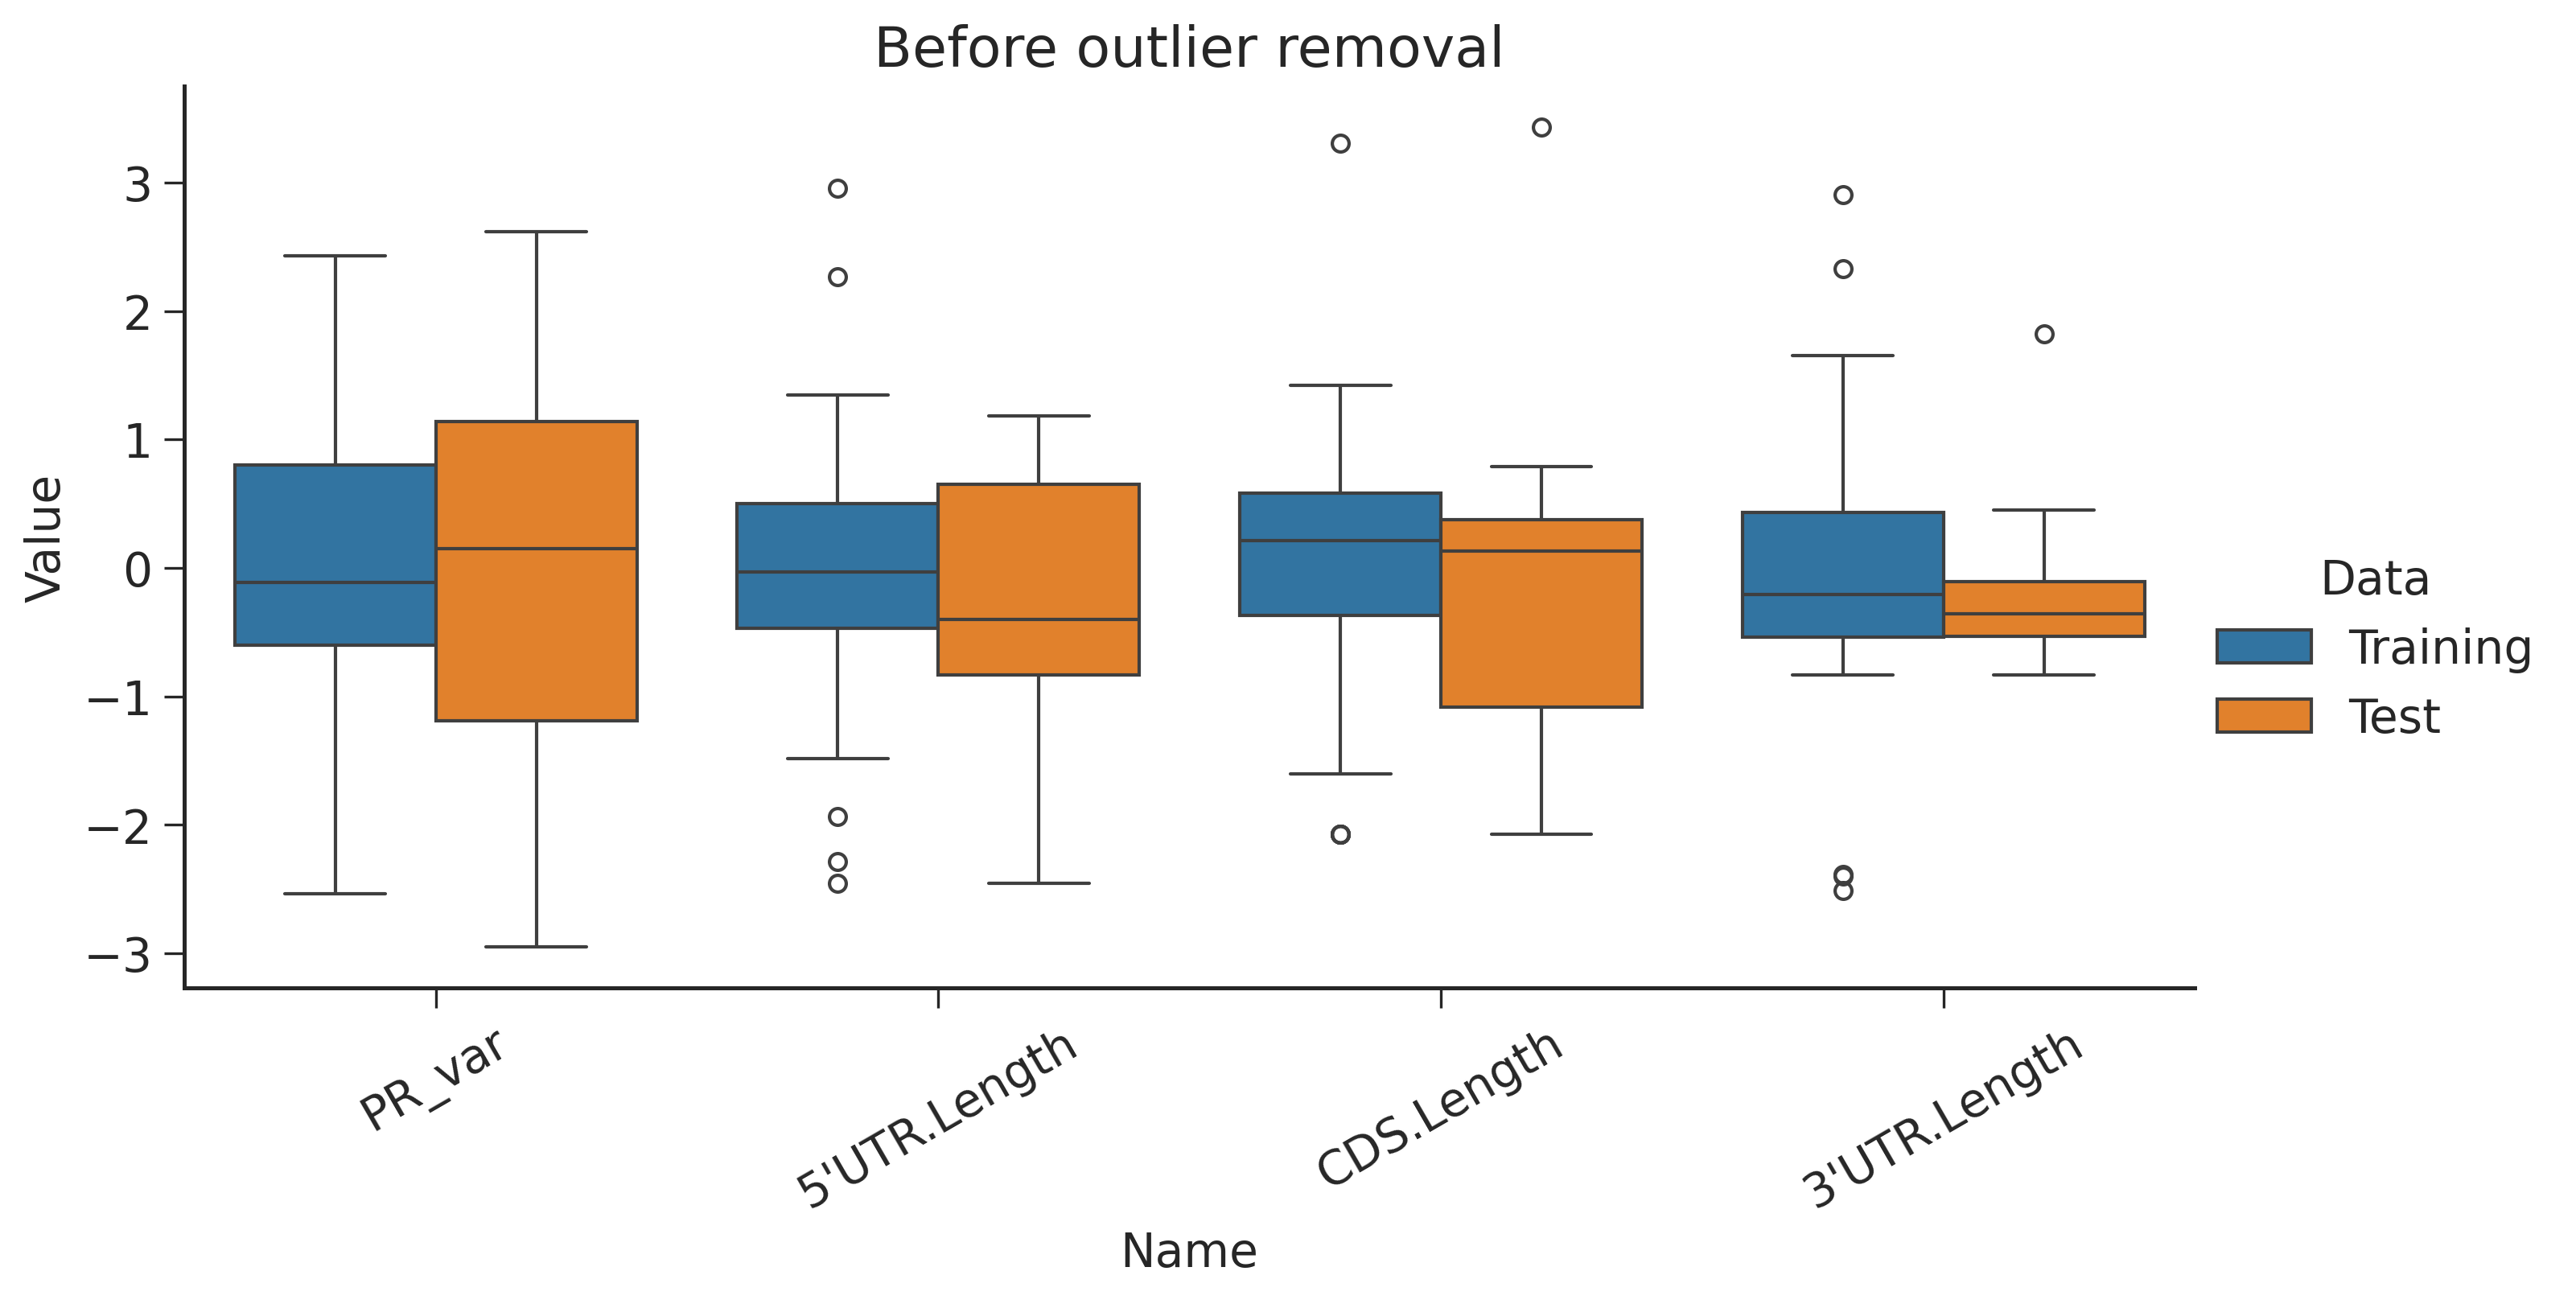

2026-06-19 21:28:41,292  WARNING: The ratio of `0.0` in `5'UTR.AAC-freq` is greater than 50% (53.06%).
2026-06-19 21:28:41,298  WARNING: The ratio of `0.0` in `5'UTR.AUA-freq` is greater than 50% (57.14%).
2026-06-19 21:28:41,309  WARNING: The ratio of `0.0` in `5'UTR.AUG-freq` is greater than 90% (95.92%).
2026-06-19 21:28:41,327  WARNING: The ratio of `0.0` in `5'UTR.AGU-freq` is greater than 50% (57.14%).
2026-06-19 21:28:41,334  WARNING: The ratio of `0.0` in `5'UTR.AGG-freq` is greater than 50% (63.27%).
2026-06-19 21:28:41,345  WARNING: The ratio of `0.0` in `5'UTR.ACA-freq` is greater than 50% (59.18%).
2026-06-19 21:28:41,351  WARNING: The ratio of `0.0` in `5'UTR.ACU-freq` is greater than 50% (51.02%).
2026-06-19 21:28:41,357  WARNING: The ratio of `0.0` in `5'UTR.ACG-freq` is greater than 50% (71.43%).
2026-06-19 21:28:41,363  WARNING: The ratio of `0.0` in `5'UTR.ACC-freq` is greater than 50% (51.02%).
2026-06-19 21:28:41,376  WARNING: The ratio of `0.0` in `5'UTR.UAU-freq` 

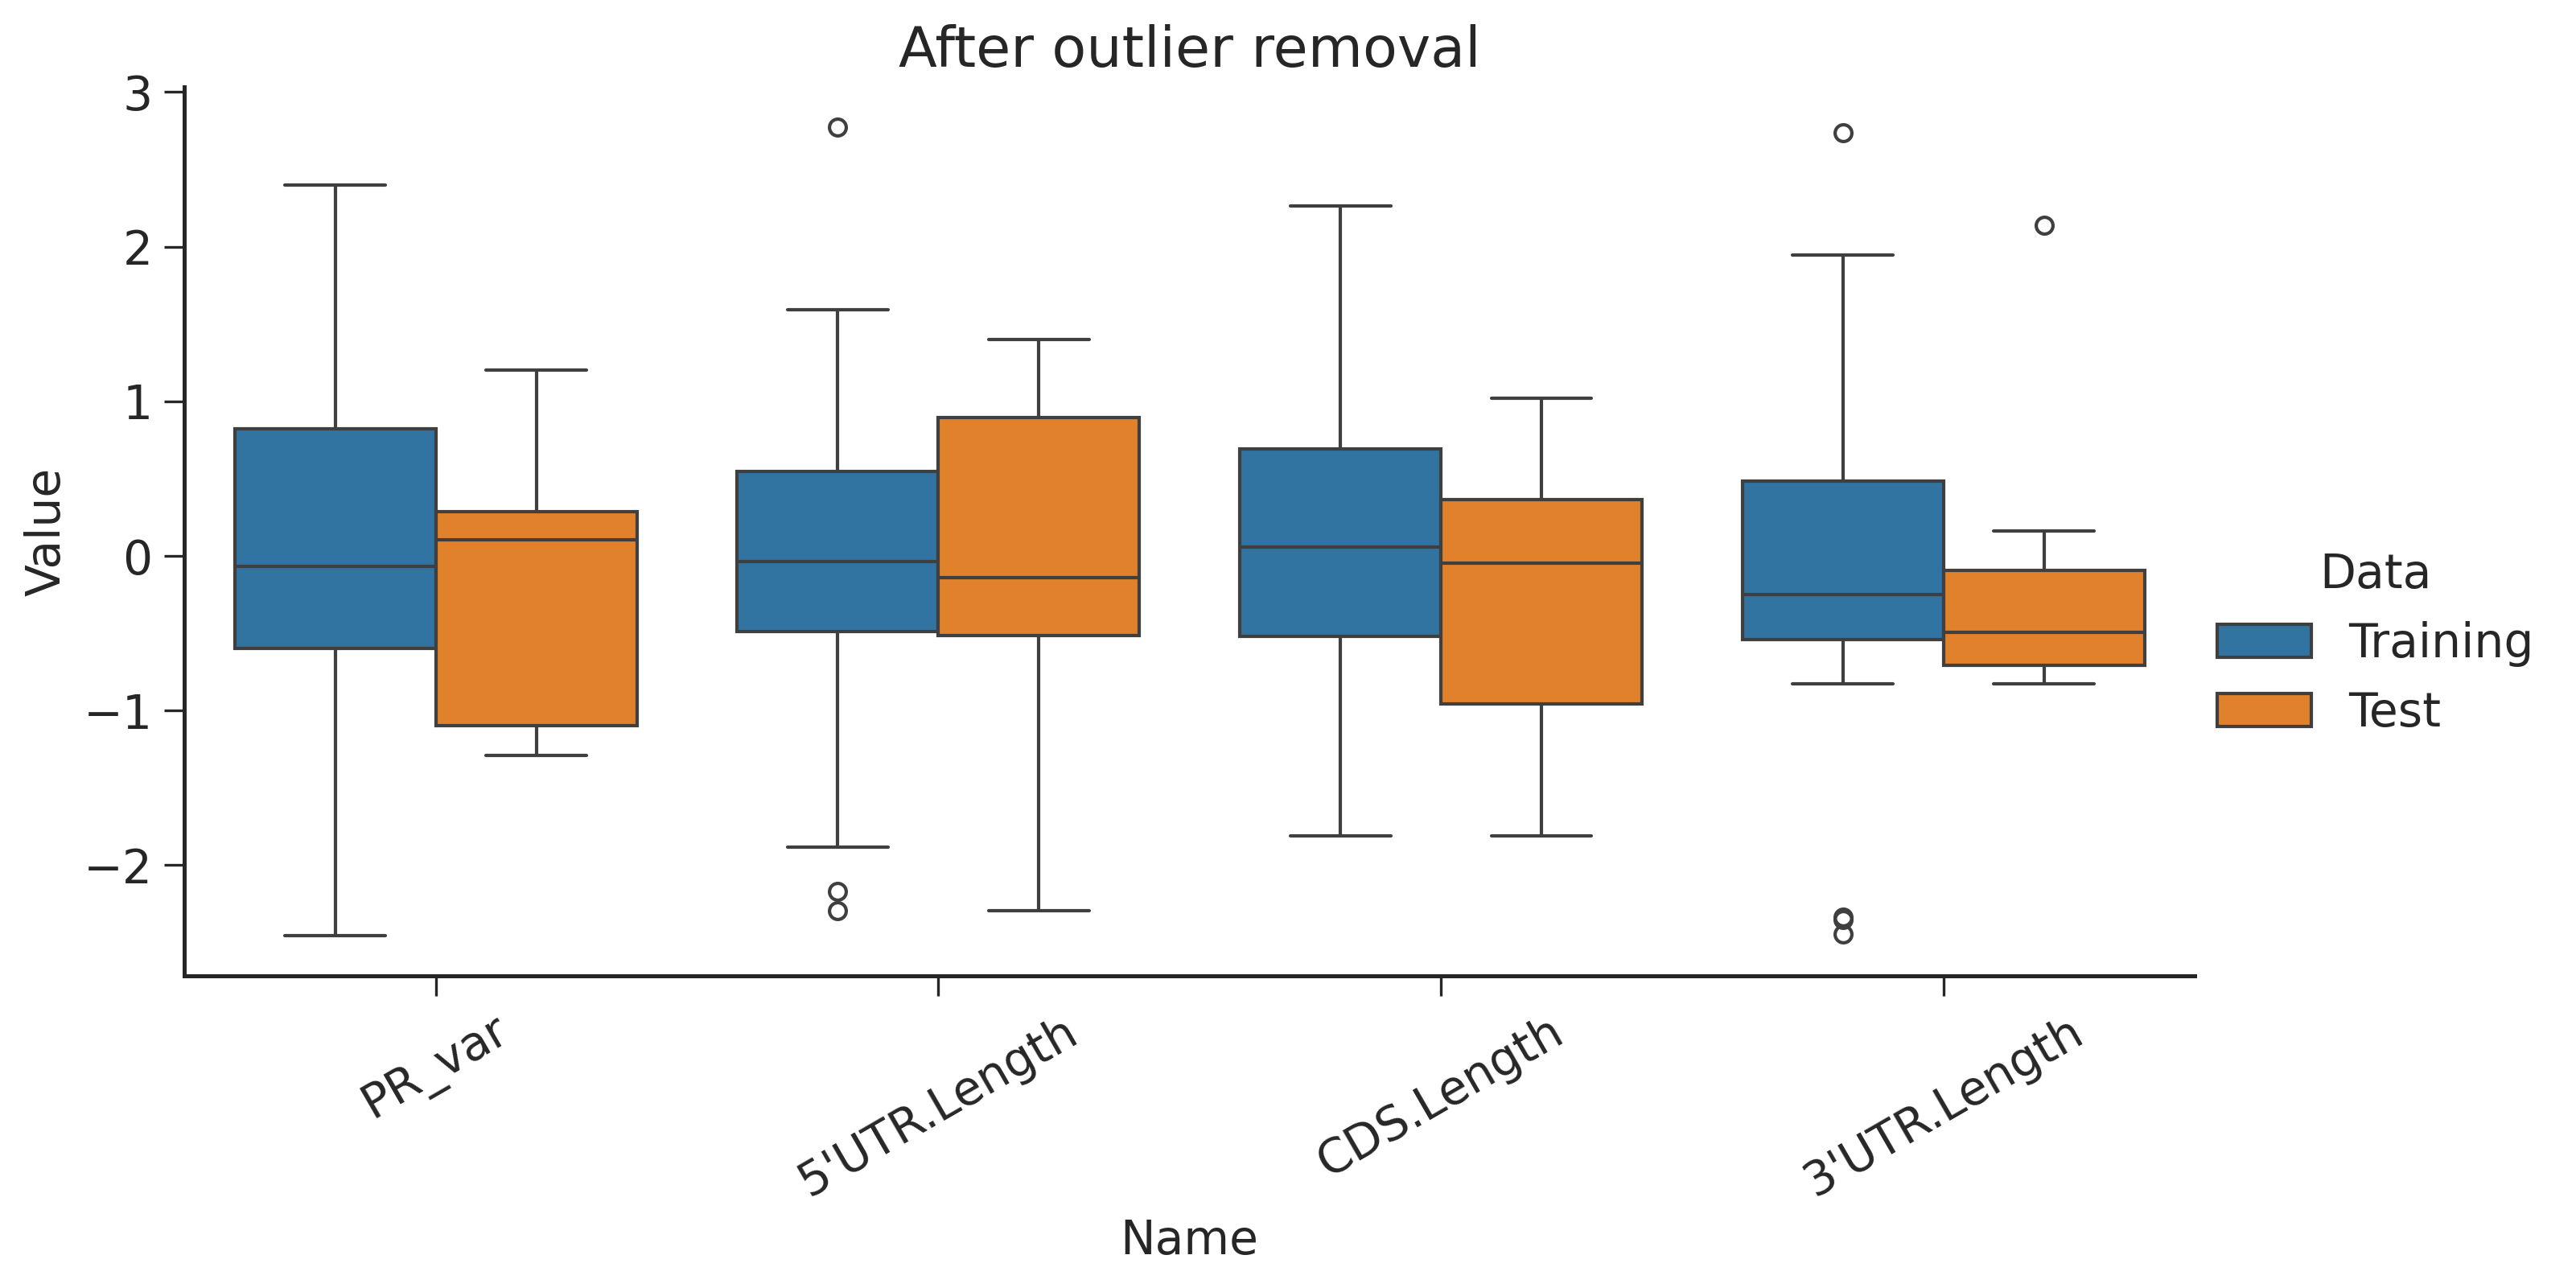

x_train: (49, 361)
x_test : (10, 361)
y_train: (49,)
y_test : (10,)


In [12]:
# ============================================
# Outlier removal and feature transformation
# ============================================

xform_method = "yeo-johnson"

# outlier_removal_method = None
outlier_removal_method = "Z-score"
# outlier_removal_method = "LOF"

z_score_expected_n = 0.5
lof_contamination = "auto"

outlier_det_col_list = [
    "5'UTR.Length",
    "CDS.Length",
    "3'UTR.Length",
]

if is_xformed:
    raise Exception(
        "Data has already been transformed. "
        "If you want to reconvert, restart from the train/test split."
    )


def detect_outliers(
    xformed_train_array,
    xformed_test_array,
    removal_method,
    z_score_expected_n=0.5,
    lof_contamination="auto",
):
    if removal_method is None:
        train_bool_array = np.ones(len(xformed_train_array), dtype=bool)
        test_bool_array = np.ones(len(xformed_test_array), dtype=bool)

    elif removal_method == "Z-score":
        min_thresh = stats.norm.ppf(
            (z_score_expected_n / 2) / len(xformed_train_array),
            loc=0,
            scale=1,
        )
        max_thresh = -min_thresh

        train_bool_array = (
            (xformed_train_array >= min_thresh)
            & (xformed_train_array <= max_thresh)
        )
        test_bool_array = (
            (xformed_test_array >= min_thresh)
            & (xformed_test_array <= max_thresh)
        )

    elif removal_method == "LOF":
        clf = LocalOutlierFactor(
            novelty=True,
            contamination=lof_contamination,
        ).fit(xformed_train_array.reshape(-1, 1))

        train_bool_array = clf.predict(
            xformed_train_array.reshape(-1, 1)
        ) == 1

        test_bool_array = clf.predict(
            xformed_test_array.reshape(-1, 1)
        ) == 1

    else:
        raise ValueError(f"Unknown outlier removal method: {removal_method}")

    return train_bool_array, test_bool_array


# ============================================
# Pre-transform y for outlier detection
# ============================================

pre_y_train, y_xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
    y_train,
    xform_method=xform_method,
    should_stdzn=True,
)

pre_y_test = sylib.utils.xform_array(
    y_test,
    **y_xform_kwargs,
)

temp_df_dict = {
    "Name": [score_col_name] * (len(y_train) + len(y_test)),
    "Data": ["Training"] * len(y_train) + ["Test"] * len(y_test),
    "Value": list(pre_y_train) + list(pre_y_test),
}


# ============================================
# Detect outliers from y
# ============================================

train_bool_array, test_bool_array = detect_outliers(
    pre_y_train,
    pre_y_test,
    outlier_removal_method,
    z_score_expected_n=z_score_expected_n,
    lof_contamination=lof_contamination,
)

logger.info(
    "Number of %s outliers in training data = %s",
    score_col_name,
    len(y_train) - sum(train_bool_array),
)

logger.info(
    "Number of %s outliers in test data     = %s",
    score_col_name,
    len(y_test) - sum(test_bool_array),
)


# ============================================
# Detect outliers from selected feature columns
# ============================================

if len(outlier_det_col_list) > 0:
    for col_name in outlier_det_col_list:

        if col_name not in x_train.columns:
            logger.warning("%s was skipped because it is not in x_train.", col_name)
            continue

        if x_train[col_name].var() == 0:
            continue

        xformed_train_array, xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
            x_train[col_name],
            xform_method=xform_method,
            should_stdzn=True,
        )

        xformed_test_array = sylib.utils.xform_array(
            x_test[col_name],
            **xform_kwargs,
        )

        temp_train_bool_array, temp_test_bool_array = detect_outliers(
            xformed_train_array,
            xformed_test_array,
            outlier_removal_method,
            z_score_expected_n=z_score_expected_n,
            lof_contamination=lof_contamination,
        )

        temp_df_dict["Name"] += [col_name] * (len(y_train) + len(y_test))
        temp_df_dict["Data"] += ["Training"] * len(y_train) + ["Test"] * len(y_test)
        temp_df_dict["Value"] += list(xformed_train_array) + list(xformed_test_array)

        logger.info(
            "Number of %s outliers in training data = %s",
            col_name,
            len(y_train) - sum(temp_train_bool_array),
        )

        logger.info(
            "Number of %s outliers in test data     = %s",
            col_name,
            len(y_test) - sum(temp_test_bool_array),
        )

        train_bool_array &= temp_train_bool_array
        test_bool_array &= temp_test_bool_array

    logger.info(
        "Number of all outliers in training data = %s",
        len(y_train) - sum(train_bool_array),
    )

    logger.info(
        "Number of all outliers in test data     = %s",
        len(y_test) - sum(test_bool_array),
    )


# ============================================
# Plot before outlier removal
# ============================================

width = max(4, 8 * max(1, len(outlier_det_col_list)) / 2.54)
height = 12 / 2.54

g = sns.catplot(
    x="Name",
    y="Value",
    hue="Data",
    data=pd.DataFrame(temp_df_dict),
    kind="box",
    height=height,
    aspect=width / height,
)

g.ax.set_title("Before outlier removal")
g.ax.tick_params(axis="x", rotation=30)

plt.show()
plt.close()


# ============================================
# Remove outliers
# ============================================

y_train = y_train[train_bool_array]
y_test = y_test[test_bool_array]

if group_col_name is not None:
    g_train = g_train[train_bool_array]
    g_test = g_test[test_bool_array]

x_train = x_train[train_bool_array].copy()
x_test = x_test[test_bool_array].copy()


# ============================================
# Transform y after outlier removal
# ============================================

y_train, y_xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
    y_train,
    xform_method=xform_method,
    should_stdzn=True,
)

y_test = sylib.utils.xform_array(
    y_test,
    **y_xform_kwargs,
)

temp_df_dict = {
    "Name": [score_col_name] * (len(y_train) + len(y_test)),
    "Data": ["Training"] * len(y_train) + ["Test"] * len(y_test),
    "Value": list(y_train) + list(y_test),
}


# ============================================
# Transform feature matrix
# ============================================

x_xform_param_dict = {}

for col_name in list(x_train.columns):

    if x_train[col_name].var() == 0:
        del x_train[col_name]
        del x_test[col_name]

        logger.warning(
            "%s was removed because the variance is 0.",
            col_name,
        )

        x_xform_param_dict[col_name] = None
        continue

    most_common_key, most_common_n = collections.Counter(
        x_train[col_name]
    ).most_common()[0]

    for p in [0.99, 0.90, 0.75, 0.50]:
        if most_common_n / len(x_train) > p:
            logger.warning(
                "The ratio of `%s` in `%s` is greater than %s%% (%s%%).",
                most_common_key,
                col_name,
                round(p * 100),
                round(most_common_n / len(x_train) * 100, 2),
            )
            break

    if len(set(x_train[col_name])) == 2:
        x_train[col_name], xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
            x_train[col_name],
            xform_method=None,
            should_stdzn=True,
        )
    else:
        x_train[col_name], xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
            x_train[col_name],
            xform_method=xform_method,
            should_stdzn=True,
        )

    x_test[col_name] = sylib.utils.xform_array(
        x_test[col_name],
        **xform_kwargs,
    )

    x_xform_param_dict[col_name] = xform_kwargs


# ============================================
# Plot after outlier removal
# ============================================

for col_name in outlier_det_col_list:
    if col_name not in x_train.columns:
        continue

    temp_df_dict["Name"] += [col_name] * (len(y_train) + len(y_test))
    temp_df_dict["Data"] += ["Training"] * len(y_train) + ["Test"] * len(y_test)
    temp_df_dict["Value"] += list(x_train[col_name]) + list(x_test[col_name])

g = sns.catplot(
    x="Name",
    y="Value",
    hue="Data",
    data=pd.DataFrame(temp_df_dict),
    kind="box",
    height=height,
    aspect=width / height,
)

g.ax.set_title("After outlier removal")
g.ax.tick_params(axis="x", rotation=30)

plt.show()
plt.close()


is_xformed = True

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

In [13]:
# ============================================
# Random Forest: objective function for Optuna
# ============================================

n_jobs = 10
k_cv = 10
n_trials = 20

n_estimators = 500

max_max_depth = 30
min_min_samples_leaf = 1


def get_cv_for_rf(k_cv=10, random_state=0):
    if group_col_name is None:
        effective_k_cv = min(k_cv, len(y_train))

        cv = model_selection.KFold(
            n_splits=effective_k_cv,
            shuffle=True,
            random_state=random_state,
        )

        cv_groups = None

    else:
        random.seed(random_state)
        np.random.seed(random_state)

        n_groups = len(set(g_train))
        effective_k_cv = min(k_cv, n_groups)

        cv = model_selection.GroupKFold(
            n_splits=effective_k_cv,
        )

        cv_groups = g_train

    return cv, cv_groups


def objective_rf(trial):
    max_depth_choice = trial.suggest_categorical(
        "max_depth",
        [None, 5, 10, 15, 20, 30],
    )

    params = {
        "max_depth": max_depth_choice,

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            min_min_samples_leaf,
            10,
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20,
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
        ),
    }

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=0,
        n_jobs=1,
        **params,
    )

    cv, cv_groups = get_cv_for_rf(
        k_cv=k_cv,
        random_state=0,
    )

    scores = model_selection.cross_validate(
        model,
        x_train,
        y_train,
        cv=cv,
        groups=cv_groups,
        n_jobs=n_jobs,
        scoring="r2",
        return_train_score=False,
        error_score=np.nan,
    )

    mean_score = np.nanmean(scores["test_score"])

    if np.isnan(mean_score):
        return -1e9

    return mean_score


# ============================================
# Random Forest: run Optuna study
# ============================================

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=0),
)

study_rf.optimize(
    objective_rf,
    n_trials=n_trials,
    show_progress_bar=True,
)

best_params_rf = study_rf.best_params
best_value_rf = study_rf.best_value

logger.info("Best RF params: %s", best_params_rf)
logger.info("Best RF CV R2: %0.4f", best_value_rf)


# ============================================
# Collect Optuna trial results
# ============================================

cv_results_rf = []

for trial in study_rf.get_trials():
    row = {
        "trial": trial.number,
        "value": trial.value,
        "state": str(trial.state),
    }
    row.update(trial.params)
    cv_results_rf.append(row)

gs_result_rf_df = (
    pd.DataFrame(cv_results_rf)
    .sort_values("value", ascending=False)
    .reset_index(drop=True)
)

display(gs_result_rf_df)

for key, value in best_params_rf.items():
    print(f"Best {key} = {value}")

print(f"Best RF R2cv = {best_value_rf}")

Best trial: 12. Best value: -0.335298: 100%|██████████| 20/20 [00:07<00:00,  2.68it/s]
2026-06-19 21:31:03,618     INFO: Best RF params: {'max_depth': 30, 'min_samples_leaf': 7, 'min_samples_split': 11, 'max_features': 'log2'}
2026-06-19 21:31:03,619     INFO: Best RF CV R2: -0.3353


,trial,value,state,max_depth,min_samples_leaf,min_samples_split,max_features
0,12,-0.335298,TrialState.COMPLETE,30.0,7,11,log2
1,15,-0.348478,TrialState.COMPLETE,5.0,6,16,log2
2,11,-0.356923,TrialState.COMPLETE,30.0,6,19,log2
3,13,-0.358010,TrialState.COMPLETE,30.0,8,10,log2
4,19,-0.358010,TrialState.COMPLETE,5.0,8,10,log2
5,14,-0.365550,TrialState.COMPLETE,15.0,7,20,log2
6,6,-0.368428,TrialState.COMPLETE,30.0,4,14,log2
7,10,-0.368784,TrialState.COMPLETE,30.0,6,20,log2
8,0,-0.369111,TrialState.COMPLETE,5.0,5,18,sqrt
9,18,-0.381730,TrialState.COMPLETE,20.0,10,8,log2


Best max_depth = 30
Best min_samples_leaf = 7
Best min_samples_split = 11
Best max_features = log2
Best RF R2cv = -0.3352980896924248


In [14]:
# ============================================
# Random Forest: final model fit and evaluation
# ============================================

model_rf = RandomForestRegressor(
    n_estimators=n_estimators,
    n_jobs=n_jobs,
    random_state=0,
    **best_params_rf,
)

model_rf.fit(x_train, y_train)

pred_y_train_rf = model_rf.predict(x_train)
pred_y_test_rf = model_rf.predict(x_test)

pearson_r_train_rf, _ = stats.pearsonr(y_train, pred_y_train_rf)
pearson_r_test_rf, _ = stats.pearsonr(y_test, pred_y_test_rf)

r2_train_rf = metrics.r2_score(y_train, pred_y_train_rf)
r2_test_rf = metrics.r2_score(y_test, pred_y_test_rf)

rmse_train_rf = np.sqrt(metrics.mean_squared_error(y_train, pred_y_train_rf))
rmse_test_rf = np.sqrt(metrics.mean_squared_error(y_test, pred_y_test_rf))

mae_train_rf = metrics.mean_absolute_error(y_train, pred_y_train_rf)
mae_test_rf = metrics.mean_absolute_error(y_test, pred_y_test_rf)

rf_metric_df = pd.DataFrame([
    {
        "dataset": "Training",
        "R2": r2_train_rf,
        "Pearson_r": pearson_r_train_rf,
        "RMSE": rmse_train_rf,
        "MAE": mae_train_rf,
    },
    {
        "dataset": "Test",
        "R2": r2_test_rf,
        "Pearson_r": pearson_r_test_rf,
        "RMSE": rmse_test_rf,
        "MAE": mae_test_rf,
    },
])

display(rf_metric_df)

,dataset,R2,Pearson_r,RMSE,MAE
0,Training,0.494131,0.842905,0.711245,0.546640
1,Test,-0.170159,0.071479,0.956094,0.837334


,dataset,R2,Pearson_r,RMSE,MAE
0,Training,0.494131,0.842905,0.711245,0.546640
1,Test,-0.170159,0.071479,0.956094,0.837334


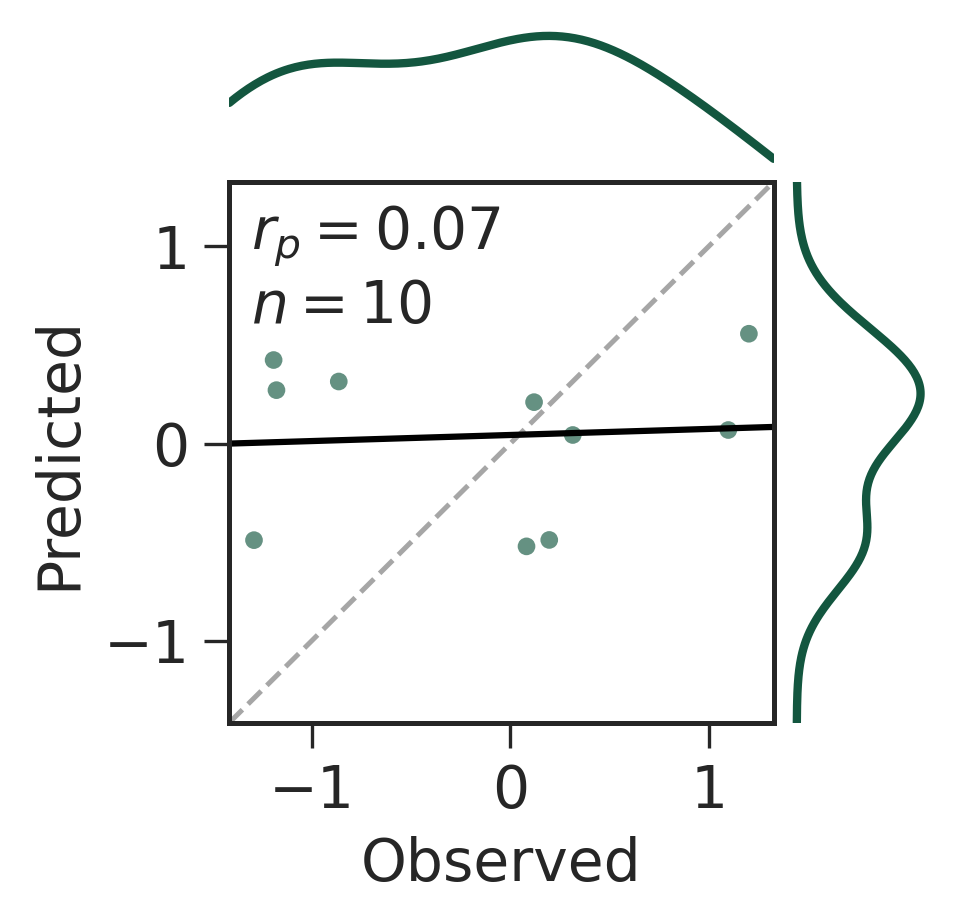

In [15]:
# ============================================
# Random Forest: prediction plot
# ============================================

display(rf_metric_df)

fig, axes = joint_scatter(
    y_test,
    pred_y_test_rf,
    color="#13563f",
    xlabel="Observed",
    ylabel="Predicted",
    figsize=(3, 3),
)

plt.show()
plt.close()

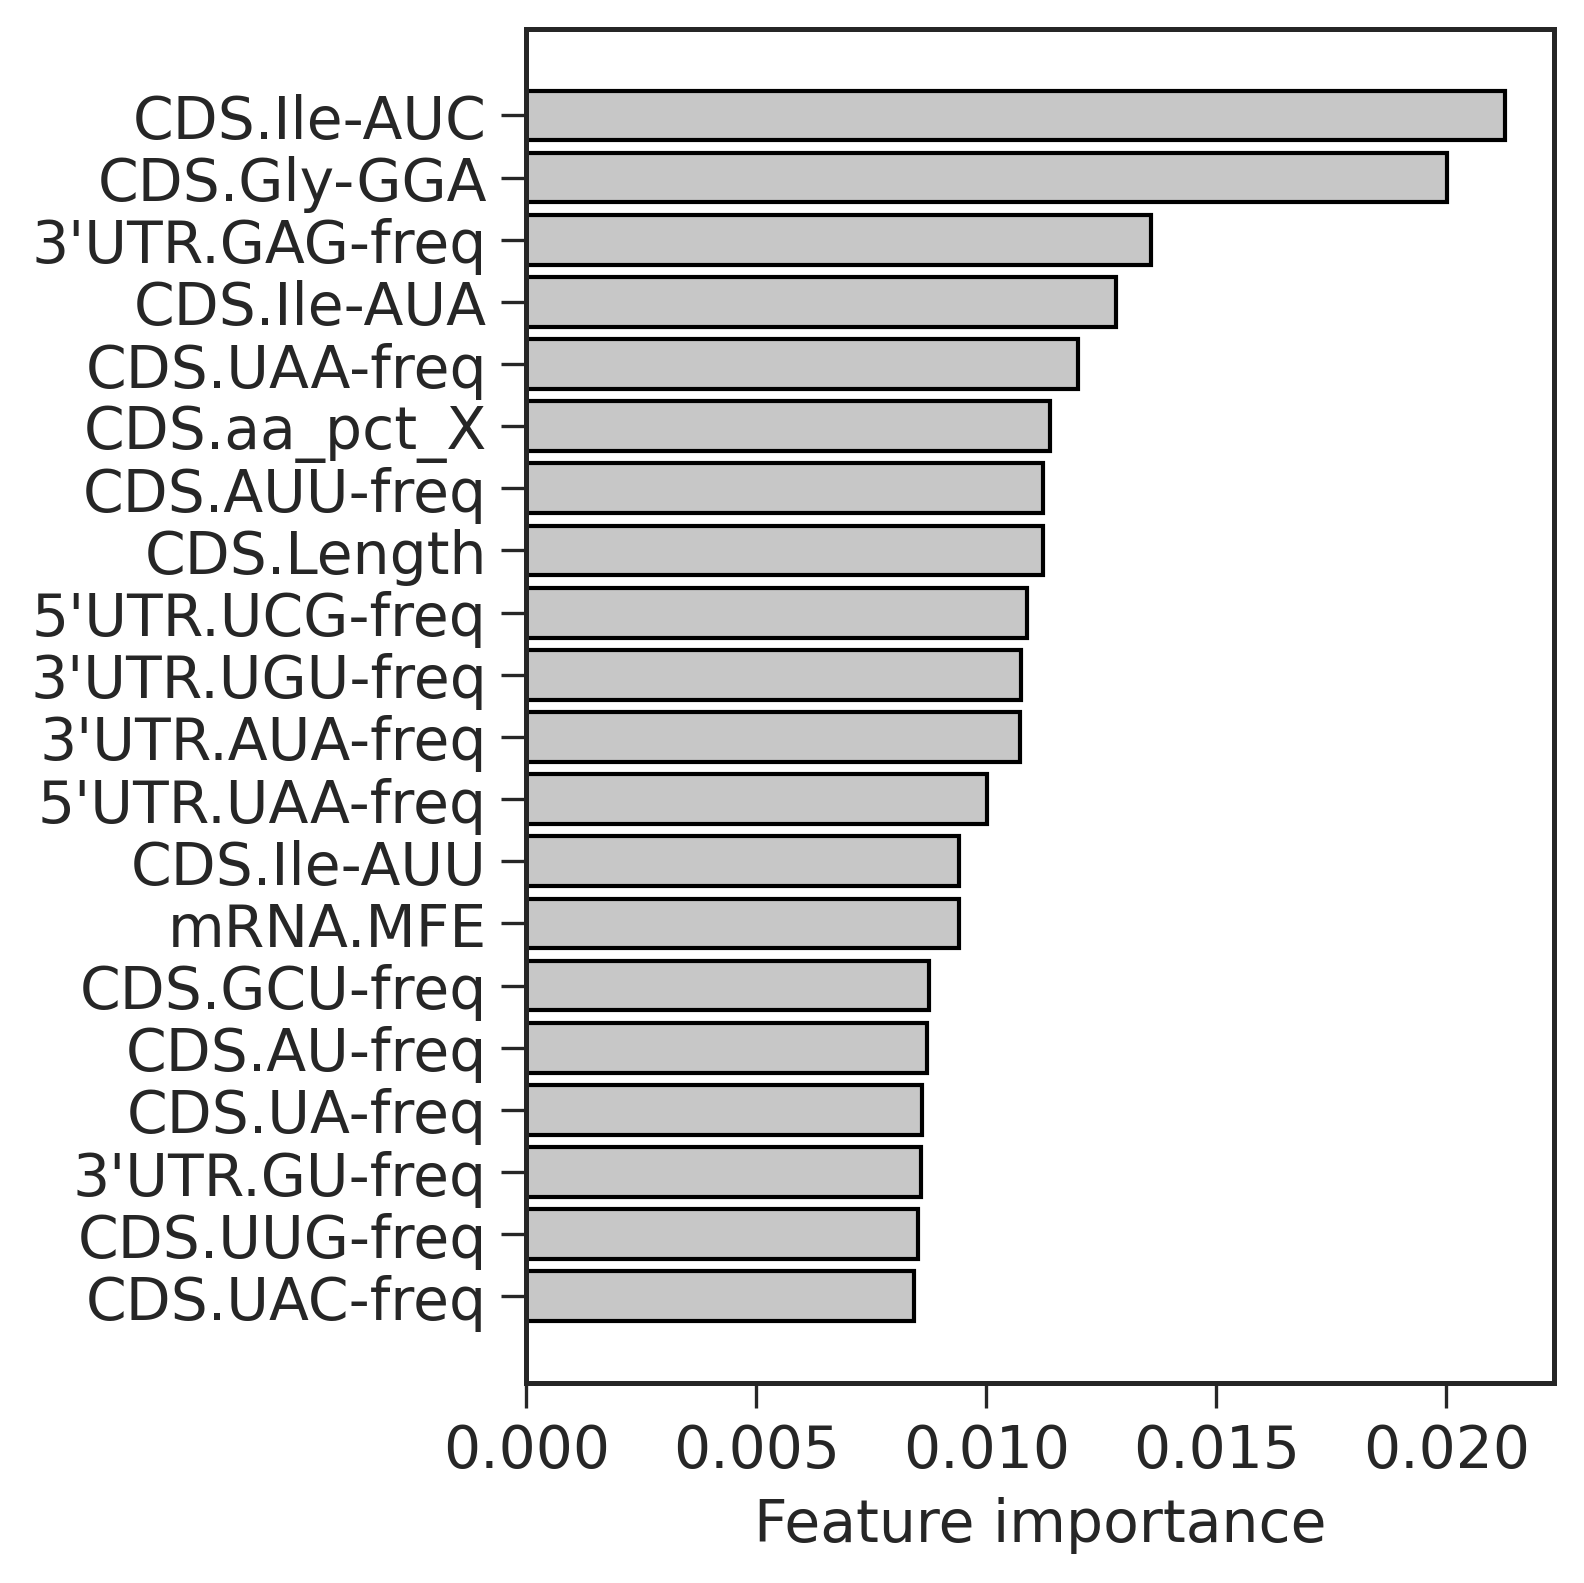

In [16]:
# ---- config ----
TOPK_IMP = 20

imp_vals = np.nan_to_num(
    np.asarray(model_rf.feature_importances_, dtype=float)
)

feat_importance_rf_df = pd.DataFrame(
    {
        "feature": x_train.columns,
        "importance": imp_vals,
    }
)

feat_importance_rf_df = feat_importance_rf_df[
    feat_importance_rf_df["importance"] > 0
].copy()

# sort by importance
feat_importance_rf_df.sort_values(
    "importance",
    ascending=False,
    inplace=True,
)

feat_importance_rf_df.reset_index(drop=True, inplace=True)

top_df = feat_importance_rf_df.head(
    TOPK_IMP if TOPK_IMP is not None else len(feat_importance_rf_df)
).iloc[::-1].copy()

fig, ax = make_fig(w=5.5, h=5.5)

bars = ax.barh(
    top_df["feature"],
    top_df["importance"].to_numpy(dtype=float),
    edgecolor="#000000",
    color="#C7C7C7",
)

format_axis(
    ax,
    xlabel="Feature importance",
    ylabel=None,
    compact_ticks=(),
)

plt.tight_layout()
plt.show()
plt.close()

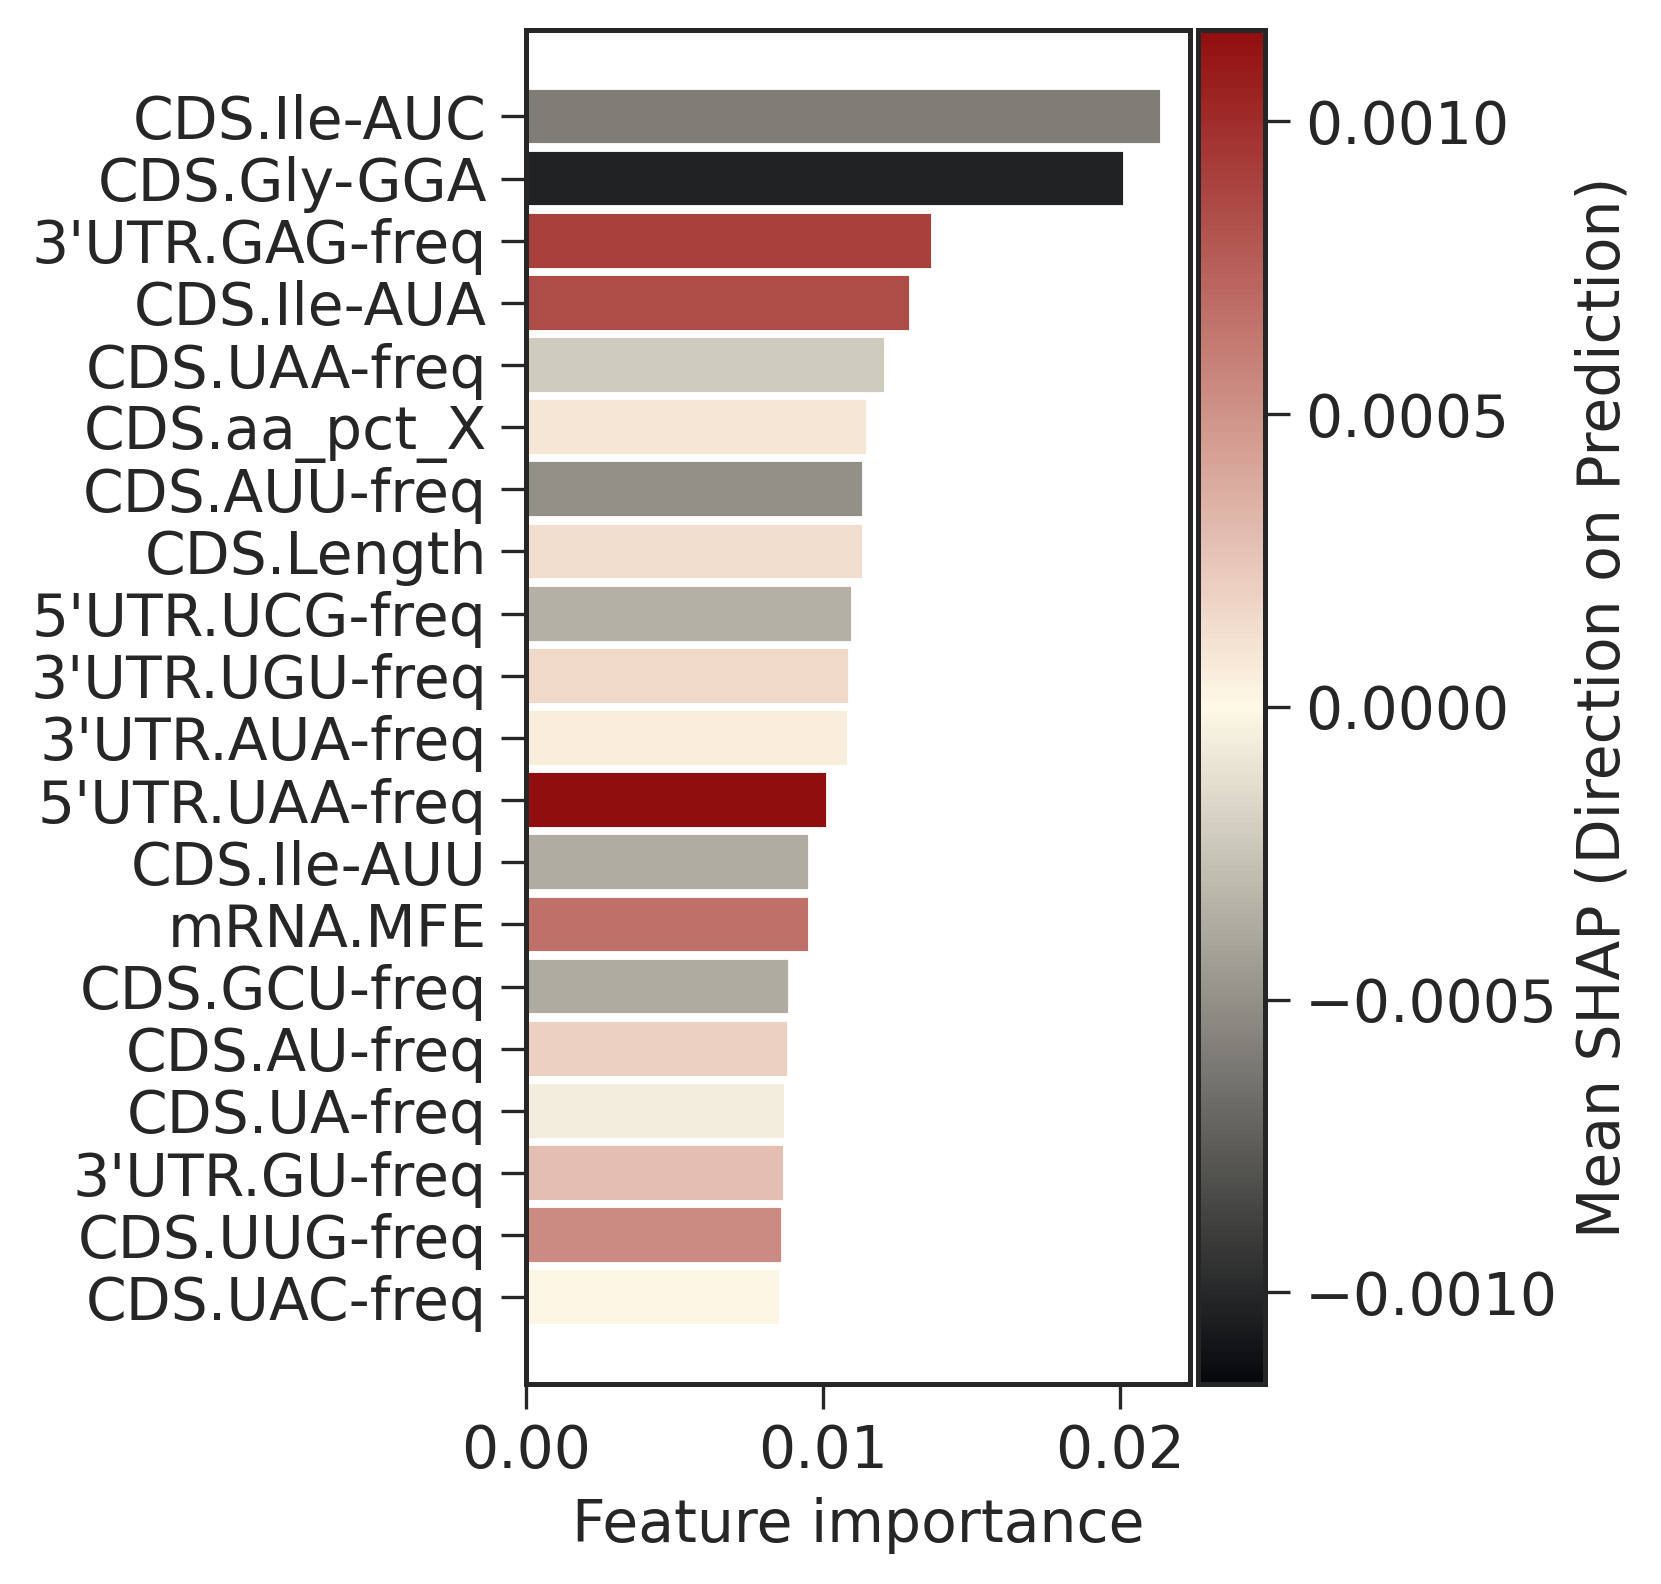

In [17]:
# ---- config ----
TOPK_IMP = 20

DrDb = LinearSegmentedColormap.from_list(
    "DrDb",
    ["#06080c", "#FFF9E7", "#910e0eff"],
)

# ------------------------------------------------
# 1) Importance dataframe from model_rf
# ------------------------------------------------

imp_vals = np.nan_to_num(
    np.asarray(model_rf.feature_importances_, dtype=float)
)

feat_importance_rf_df = pd.DataFrame(
    {
        "feature": x_train.columns,
        "importance": imp_vals,
    }
)

feat_importance_rf_df = (
    feat_importance_rf_df[feat_importance_rf_df["importance"] > 0]
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------
# 2) Compute mean SHAP per feature
# ------------------------------------------------

explainer = shap.TreeExplainer(model_rf)
shap_vals = explainer.shap_values(x_train)

mean_shap = shap_vals.mean(axis=0)
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

# ------------------------------------------------
# 3) Select top-K features and reverse for barh style
# ------------------------------------------------

top_df = feat_importance_rf_df.head(TOPK_IMP).iloc[::-1].copy()

top_df["mean_shap"] = [
    mean_shap[x_train.columns.get_loc(f)]
    for f in top_df["feature"]
]

v = top_df["mean_shap"].to_numpy()
vlim = np.max(np.abs(v)) if np.any(np.isfinite(v)) else 1.0

norm = mpl.colors.TwoSlopeNorm(
    vmin=-vlim,
    vcenter=0.0,
    vmax=vlim,
)

# ------------------------------------------------
# 4) Plot: bars colored by mean SHAP
# ------------------------------------------------

fig, ax = make_fig(w=5.5, h=5.5)

bars = ax.barh(
    top_df["feature"],
    top_df["importance"].to_numpy(dtype=float),
    edgecolor="none",
)

for b, shap_v in zip(bars, top_df["mean_shap"].to_numpy()):
    b.set_color(DrDb(norm(shap_v)))

sm = mpl.cm.ScalarMappable(
    cmap=DrDb,
    norm=norm,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.01,
)

cbar.set_label("Mean SHAP (Direction on Prediction)")

format_axis(
    ax,
    xlabel="Feature importance",
    ylabel=None,
    compact_ticks=(),
)

plt.tight_layout()
plt.show()
plt.close()